# Univariate and Bivariate Analysis of Application (Credit Bureau) Data
- table - application_train.csv
---

__Credit bureau info__:
- `AMT_REQ_CREDIT_BUREAU_HOUR` - Number of enquiries to Credit Bureau about the client one hour before application
- `AMT_REQ_CREDIT_BUREAU_DAY` - Number of enquiries to Credit Bureau about the client one day before application (excluding one hour before application)
- `AMT_REQ_CREDIT_BUREAU_WEEK` - Number of enquiries to Credit Bureau about the client one week before application (excluding one day before application)
- `AMT_REQ_CREDIT_BUREAU_MON` - Number of enquiries to Credit Bureau about the client one month before application (excluding one week before application)
- `AMT_REQ_CREDIT_BUREAU_QRT` - Number of enquiries to Credit Bureau about the client 3 month before application (excluding one month before application)
- `AMT_REQ_CREDIT_BUREAU_YEAR` - Number of enquiries to Credit Bureau about the client one day year (excluding last 3 months before application)

## 0. Data and libraries

In [44]:
import pandas as pd
import numpy as np

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_PATH = PROJECT_ROOT / 'src'

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from eda_module import (
    plot_quantitative_distribution, plot_categorical_distribution, plot_binary_distribution, 
    plot_binary_vs_binary, plot_categorical_distribution, plot_quantitative_vs_binary,
    plot_categorical_vs_binary
)
from preprocess_module import create_imputed_quantitative_features, filter_high_nans_cols, drop_obs_with_nans_in_low_nan_cols

In [45]:
app_df = pd.read_csv(r"..\data\raw\application_train.csv")
print(f"Shape of app_df: {app_df.shape}")
app_df.head(10)

Shape of app_df: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0
6,100009,0,Cash loans,F,Y,Y,1,171000.0,1560726.0,41301.0,...,0,0,0,0,0.0,0.0,0.0,1.0,1.0,2.0
7,100010,0,Cash loans,M,Y,Y,0,360000.0,1530000.0,42075.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
8,100011,0,Cash loans,F,N,Y,0,112500.0,1019610.0,33826.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
9,100012,0,Revolving loans,M,N,Y,0,135000.0,405000.0,20250.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
credit_bureau_cols = [
    'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
    'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR'
]
app_df[credit_bureau_cols].describe()

,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


## 1. AMT_REQ_CREDIT_BUREAU_HOUR

In [47]:
app_df['AMT_REQ_CREDIT_BUREAU_HOUR'].describe()

count    265992.000000
mean          0.006402
std           0.083849
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           4.000000
Name: AMT_REQ_CREDIT_BUREAU_HOUR, dtype: float64

In [48]:
app_df['AMT_REQ_CREDIT_BUREAU_HOUR'].value_counts()

AMT_REQ_CREDIT_BUREAU_HOUR
0.0    264366
1.0      1560
2.0        56
3.0         9
4.0         1
Name: count, dtype: int64

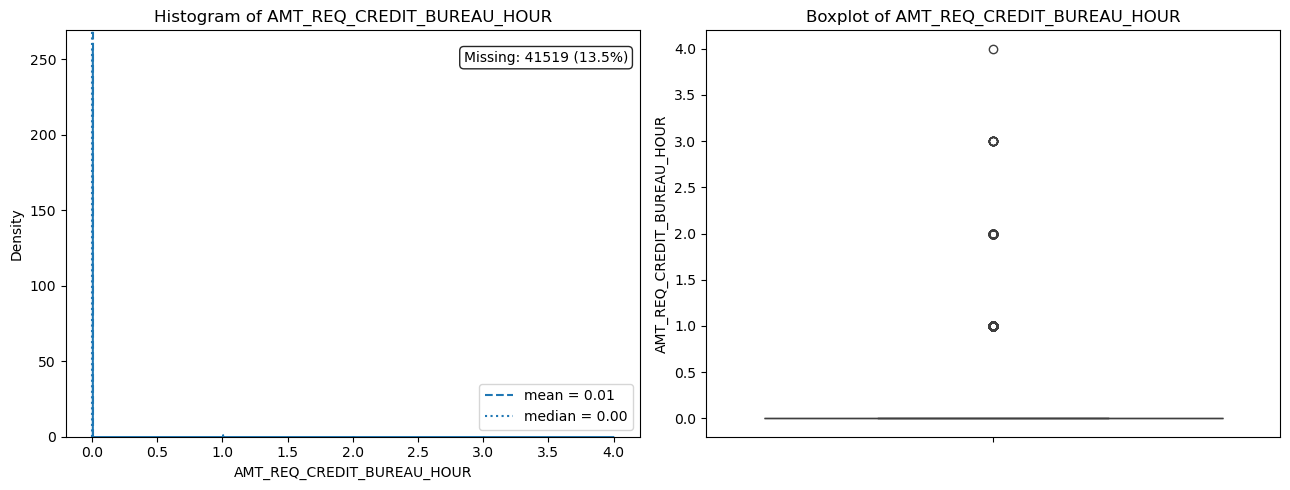

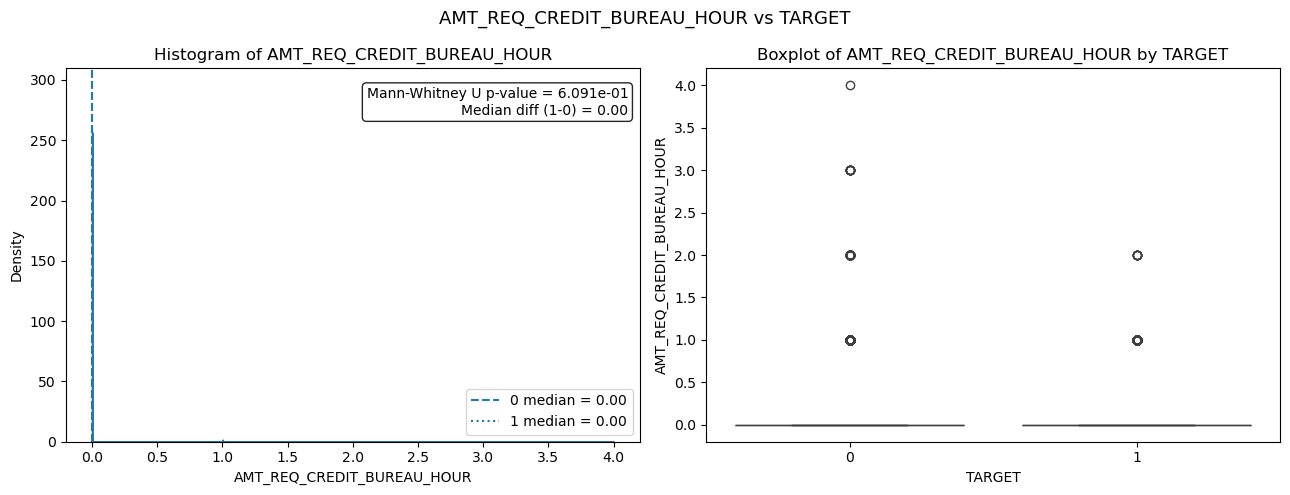

In [49]:
plot_quantitative_distribution(df=app_df, quant_var='AMT_REQ_CREDIT_BUREAU_HOUR')
plot_quantitative_vs_binary(df=app_df, quant_var='AMT_REQ_CREDIT_BUREAU_HOUR', target_var='TARGET')

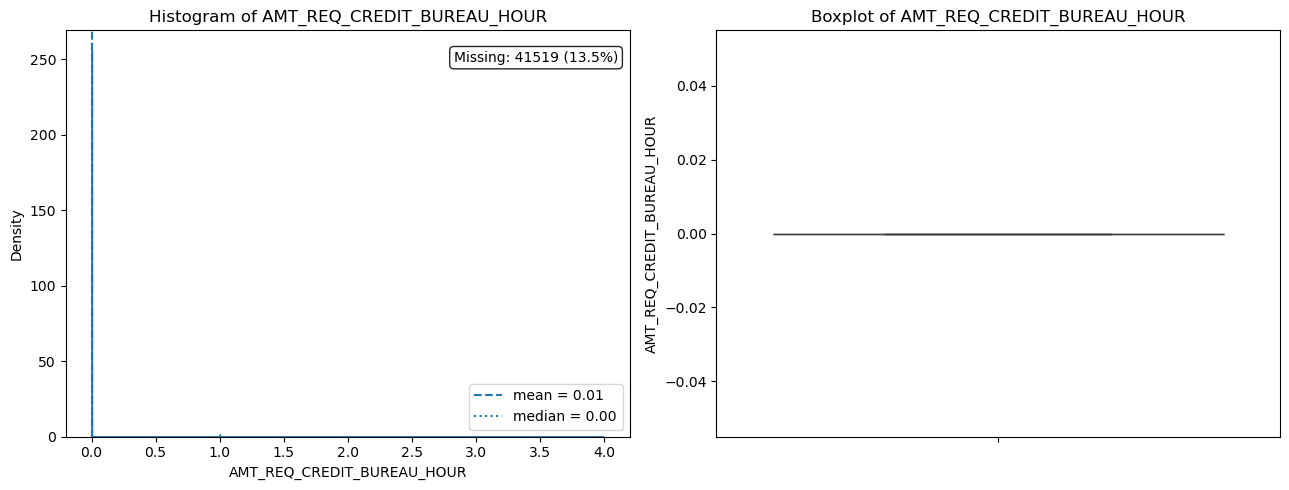

In [50]:
plot_quantitative_distribution(df=app_df, quant_var='AMT_REQ_CREDIT_BUREAU_HOUR', show_outliers=False)

## 2. AMT_REQ_CREDIT_BUREAU_DAY

In [51]:
app_df['AMT_REQ_CREDIT_BUREAU_DAY'].describe()

count    265992.000000
mean          0.007000
std           0.110757
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           9.000000
Name: AMT_REQ_CREDIT_BUREAU_DAY, dtype: float64

In [52]:
app_df['AMT_REQ_CREDIT_BUREAU_DAY'].value_counts()

AMT_REQ_CREDIT_BUREAU_DAY
0.0    264503
1.0      1292
2.0       106
3.0        45
4.0        26
5.0         9
6.0         8
9.0         2
8.0         1
Name: count, dtype: int64

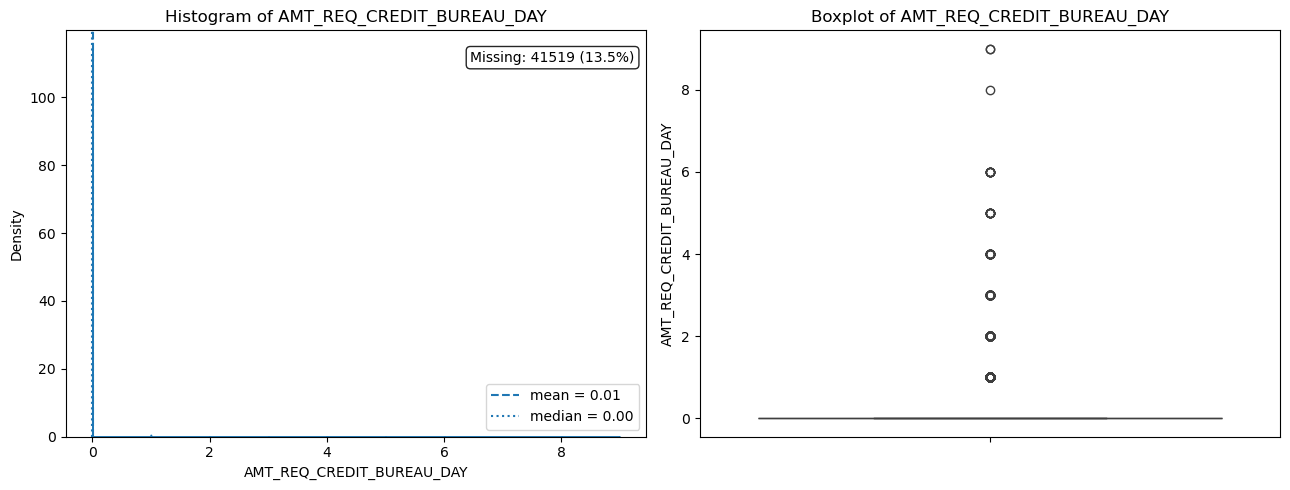

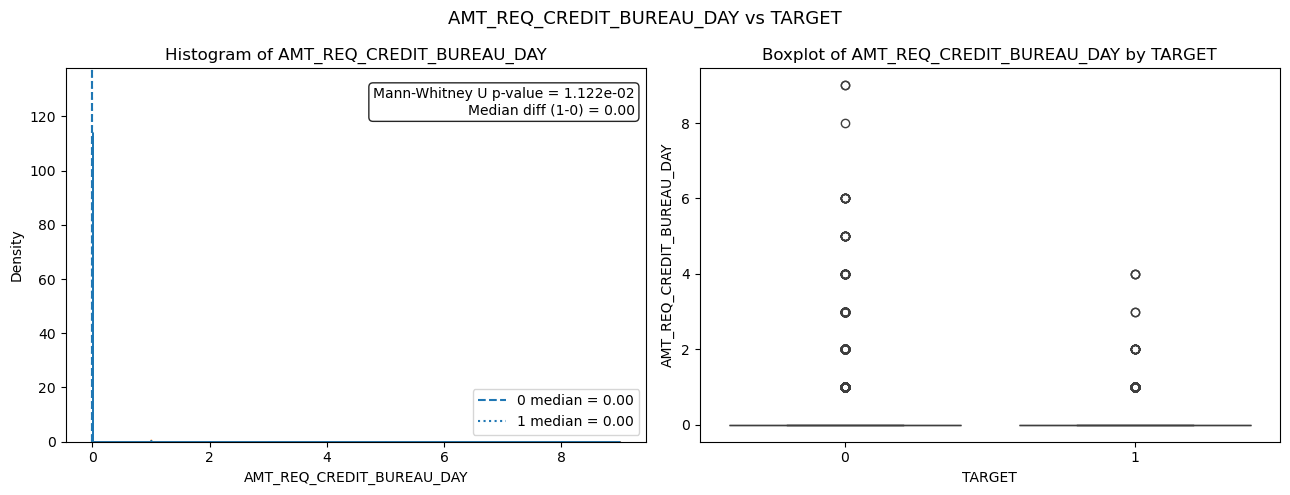

In [53]:
plot_quantitative_distribution(df=app_df, quant_var='AMT_REQ_CREDIT_BUREAU_DAY')
plot_quantitative_vs_binary(df=app_df, quant_var='AMT_REQ_CREDIT_BUREAU_DAY', target_var='TARGET')

## 3. AMT_REQ_CREDIT_BUREAU_WEEK

In [54]:
app_df['AMT_REQ_CREDIT_BUREAU_WEEK'].describe()

count    265992.000000
mean          0.034362
std           0.204685
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           8.000000
Name: AMT_REQ_CREDIT_BUREAU_WEEK, dtype: float64

In [55]:
app_df['AMT_REQ_CREDIT_BUREAU_WEEK'].value_counts()

AMT_REQ_CREDIT_BUREAU_WEEK
0.0    257456
1.0      8208
2.0       199
3.0        58
4.0        34
6.0        20
5.0        10
8.0         5
7.0         2
Name: count, dtype: int64

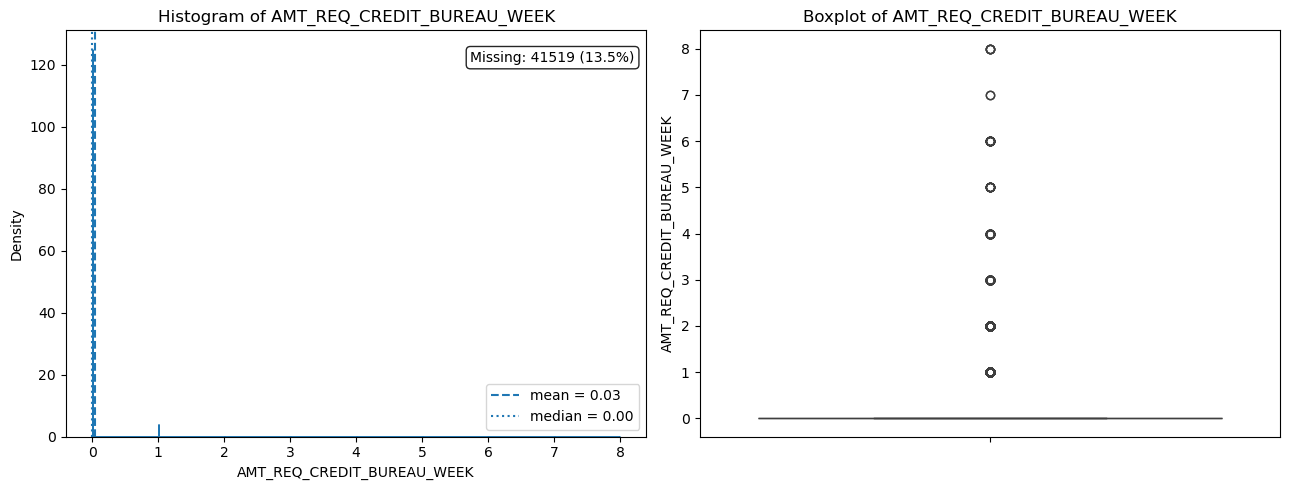

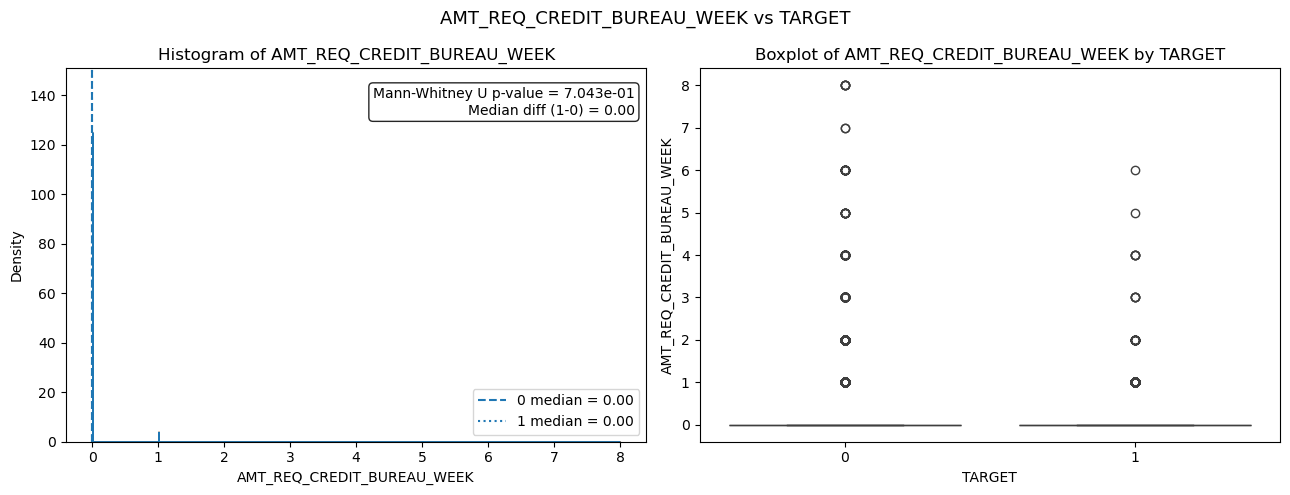

In [56]:
plot_quantitative_distribution(df=app_df, quant_var='AMT_REQ_CREDIT_BUREAU_WEEK')
plot_quantitative_vs_binary(df=app_df, quant_var='AMT_REQ_CREDIT_BUREAU_WEEK', target_var='TARGET')

## 4. AMT_REQ_CREDIT_BUREAU_MON

In [57]:
app_df['AMT_REQ_CREDIT_BUREAU_MON'].describe()

count    265992.000000
mean          0.267395
std           0.916002
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          27.000000
Name: AMT_REQ_CREDIT_BUREAU_MON, dtype: float64

In [58]:
app_df['AMT_REQ_CREDIT_BUREAU_MON'].value_counts()

AMT_REQ_CREDIT_BUREAU_MON
0.0     222233
1.0      33147
2.0       5386
3.0       1991
4.0       1076
5.0        602
6.0        343
7.0        298
9.0        206
8.0        185
10.0       132
11.0       119
12.0        77
13.0        72
14.0        40
15.0        35
16.0        23
17.0        14
18.0         6
19.0         3
24.0         1
23.0         1
27.0         1
22.0         1
Name: count, dtype: int64

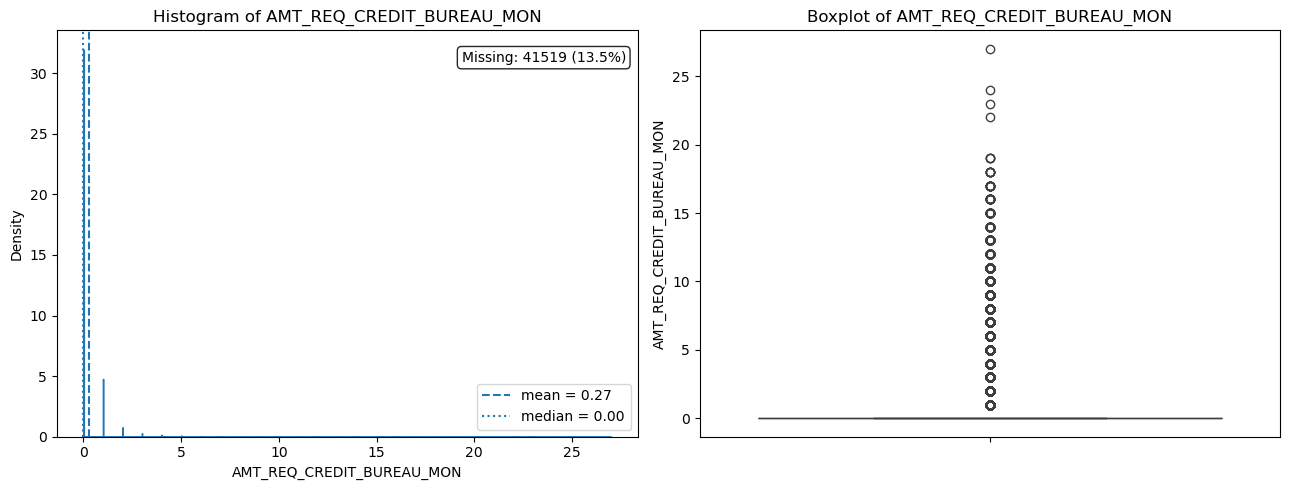

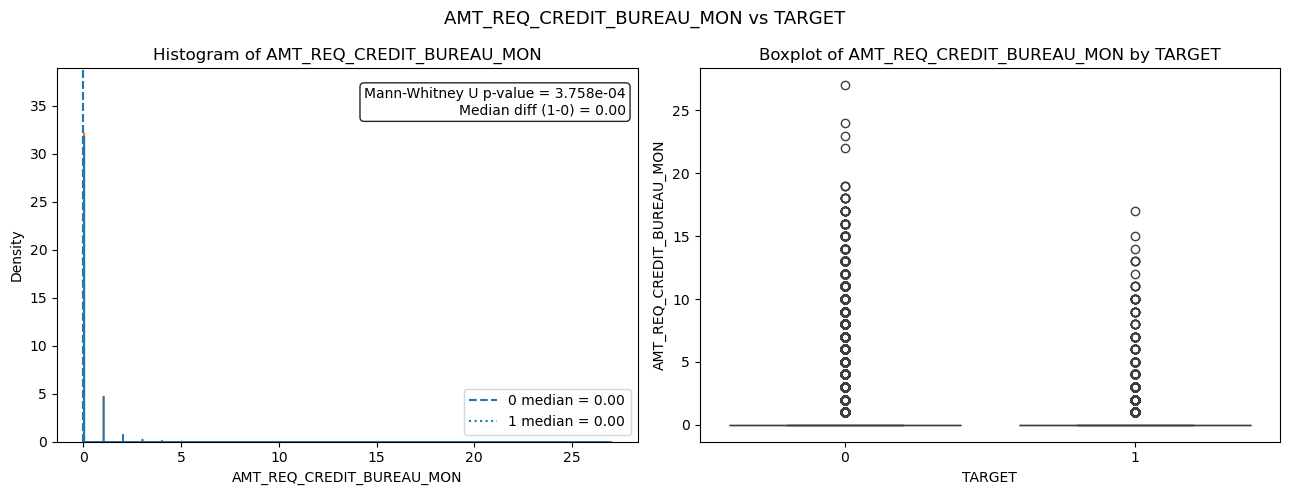

In [59]:
plot_quantitative_distribution(df=app_df, quant_var='AMT_REQ_CREDIT_BUREAU_MON')
plot_quantitative_vs_binary(df=app_df, quant_var='AMT_REQ_CREDIT_BUREAU_MON', target_var='TARGET')

In [60]:
app_df[app_df['AMT_REQ_CREDIT_BUREAU_MON']==27]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
253488,393324,0,Cash loans,M,Y,N,0,405000.0,540000.0,20925.0,...,0,0,0,0,0.0,0.0,0.0,27.0,0.0,3.0


Clearly invalid value (AMT_REQ_CREDIT_MON = 27) since AMT_REQ_CREDIT_BUREAU_QRT = 3 and AMT_REQ_CREDIT_BUREAU_YEAR = 3. 

## 5. AMT_REQ_CREDIT_BUREAU_QTR

In [61]:
app_df['AMT_REQ_CREDIT_BUREAU_QRT'].describe()

count    265992.000000
mean          0.265474
std           0.794056
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         261.000000
Name: AMT_REQ_CREDIT_BUREAU_QRT, dtype: float64

In [62]:
app_df['AMT_REQ_CREDIT_BUREAU_QRT'].value_counts()

AMT_REQ_CREDIT_BUREAU_QRT
0.0      215417
1.0       33862
2.0       14412
3.0        1717
4.0         476
5.0          64
6.0          28
8.0           7
7.0           7
261.0         1
19.0          1
Name: count, dtype: int64

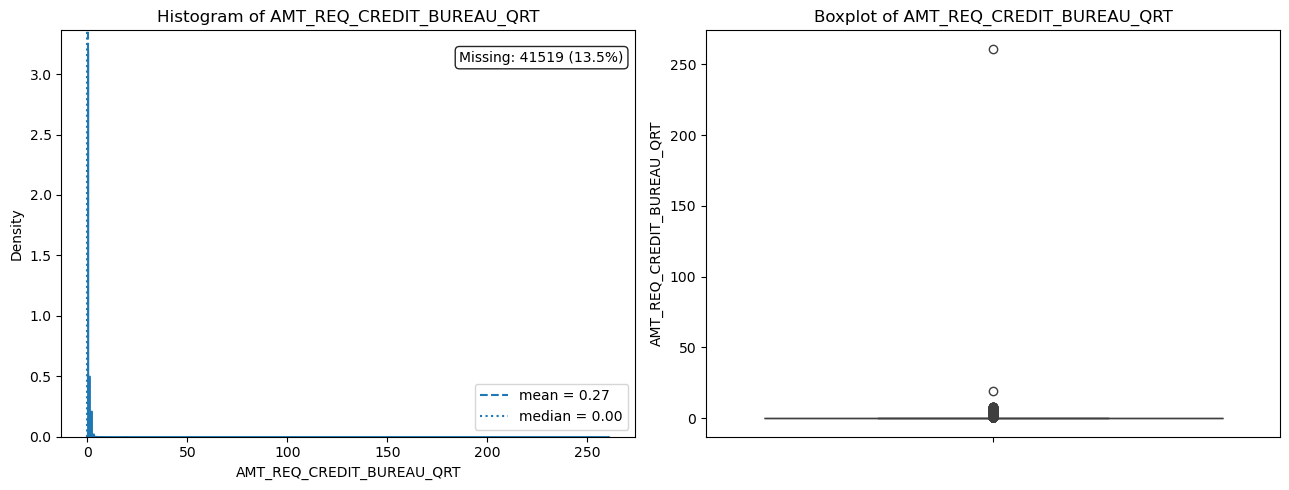

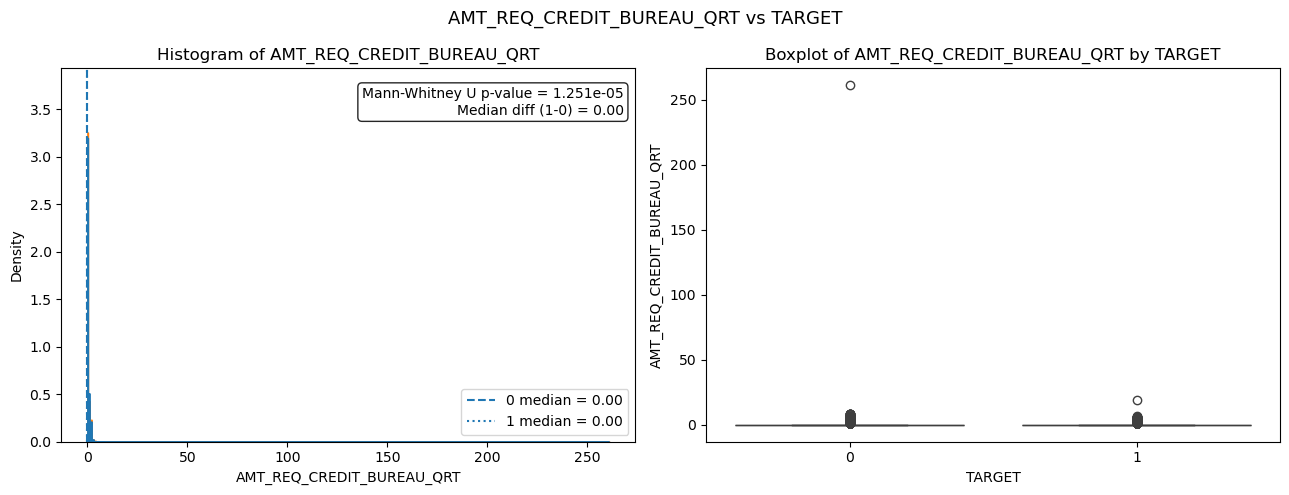

In [63]:
plot_quantitative_distribution(df=app_df, quant_var='AMT_REQ_CREDIT_BUREAU_QRT')
plot_quantitative_vs_binary(df=app_df, quant_var='AMT_REQ_CREDIT_BUREAU_QRT', target_var='TARGET')

In [64]:
app_df[app_df['AMT_REQ_CREDIT_BUREAU_QRT']== 261]

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
239474,377322,0,Cash loans,F,N,Y,1,360000.0,1035000.0,30393.0,...,0,0,0,0,0.0,0.0,0.0,1.0,261.0,0.0


Clearly invalid value (AMT_REQ_CREDIT_BUREAU_QRT = 261)

In [65]:
app_df[app_df['AMT_REQ_CREDIT_BUREAU_QRT'] != 261]['AMT_REQ_CREDIT_BUREAU_QRT'].describe()

count    265991.000000
mean          0.264494
std           0.612326
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          19.000000
Name: AMT_REQ_CREDIT_BUREAU_QRT, dtype: float64

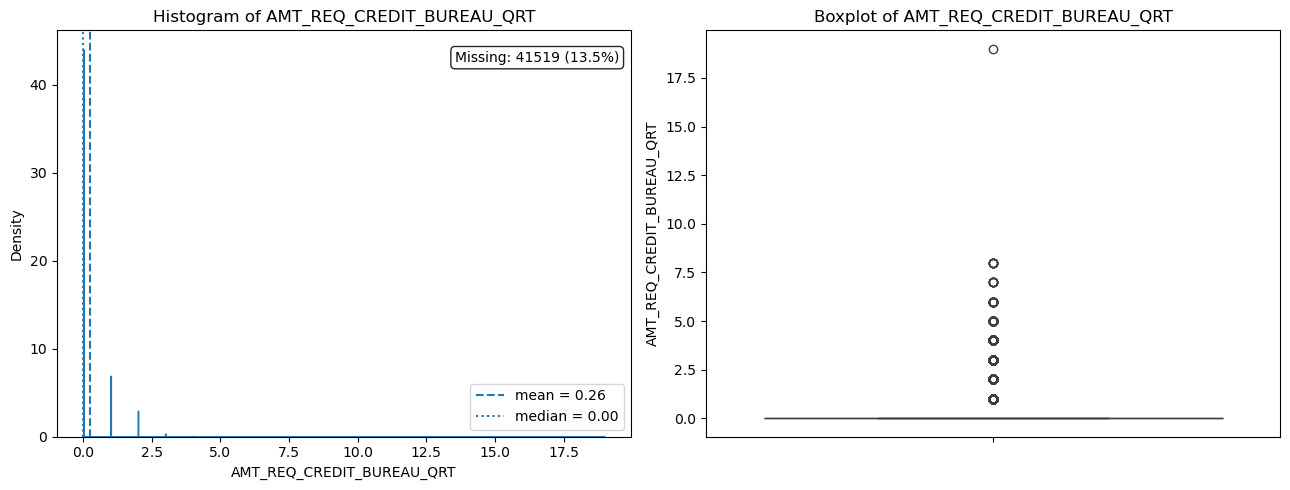

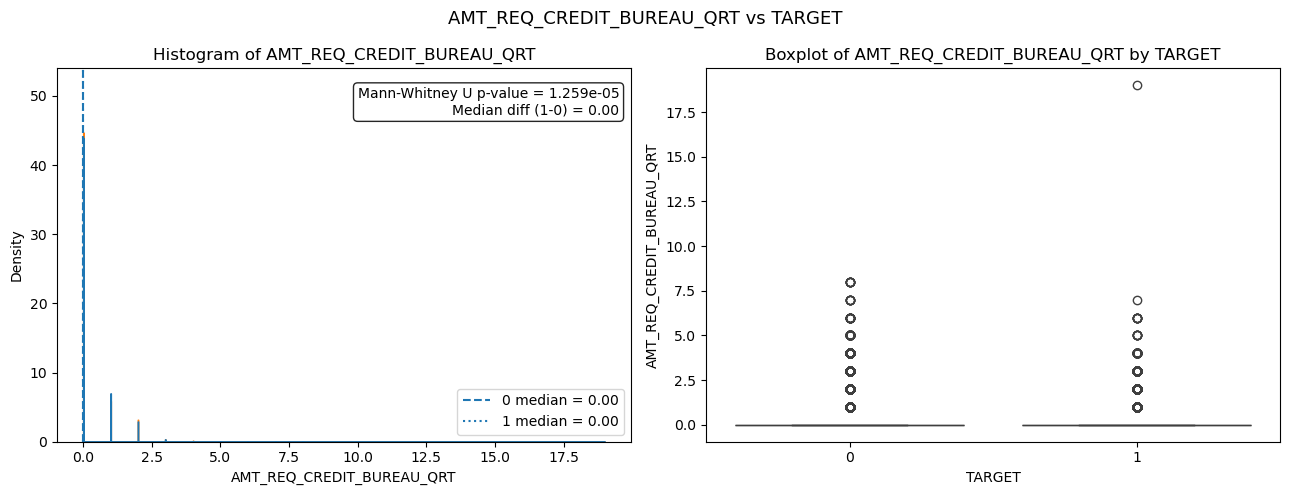

In [66]:
plot_quantitative_distribution(df=app_df[app_df['AMT_REQ_CREDIT_BUREAU_QRT'] != 261], quant_var='AMT_REQ_CREDIT_BUREAU_QRT')
plot_quantitative_vs_binary(df=app_df[app_df['AMT_REQ_CREDIT_BUREAU_QRT'] != 261], quant_var='AMT_REQ_CREDIT_BUREAU_QRT', target_var='TARGET')

## 6. AMT_REQ_CREDIT_BUREAU_YEAR

In [67]:
app_df['AMT_REQ_CREDIT_BUREAU_YEAR'].describe()

count    265992.000000
mean          1.899974
std           1.869295
min           0.000000
25%           0.000000
50%           1.000000
75%           3.000000
max          25.000000
Name: AMT_REQ_CREDIT_BUREAU_YEAR, dtype: float64

In [68]:
app_df['AMT_REQ_CREDIT_BUREAU_YEAR'].value_counts()

AMT_REQ_CREDIT_BUREAU_YEAR
0.0     71801
1.0     63405
2.0     50192
3.0     33628
4.0     20714
5.0     12052
6.0      6967
7.0      3869
8.0      2127
9.0      1096
11.0       31
12.0       30
10.0       22
13.0       19
14.0       10
17.0        7
15.0        6
18.0        4
19.0        4
16.0        3
25.0        1
23.0        1
22.0        1
21.0        1
20.0        1
Name: count, dtype: int64

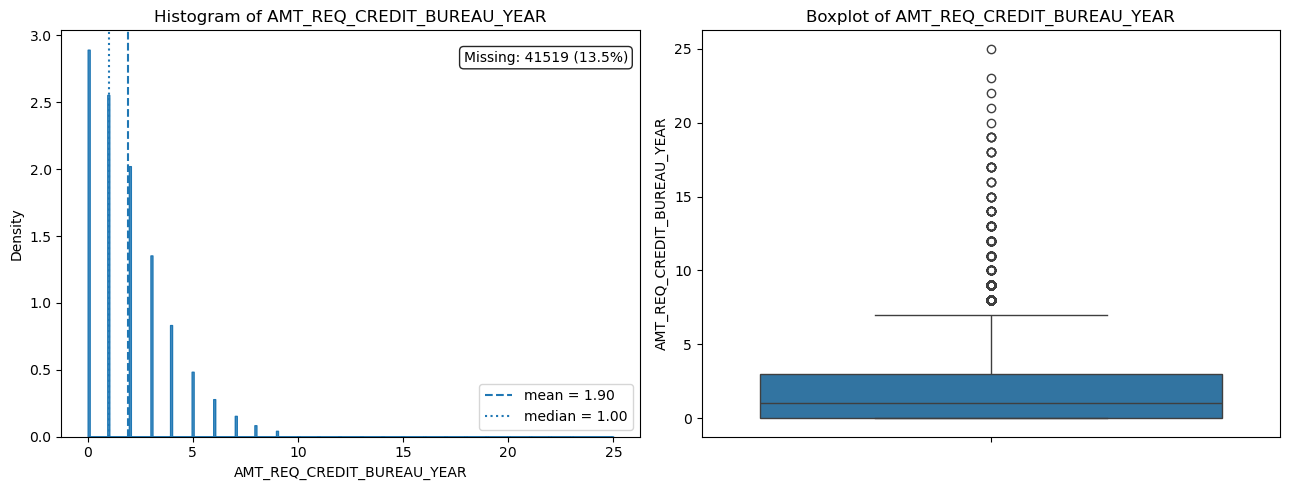

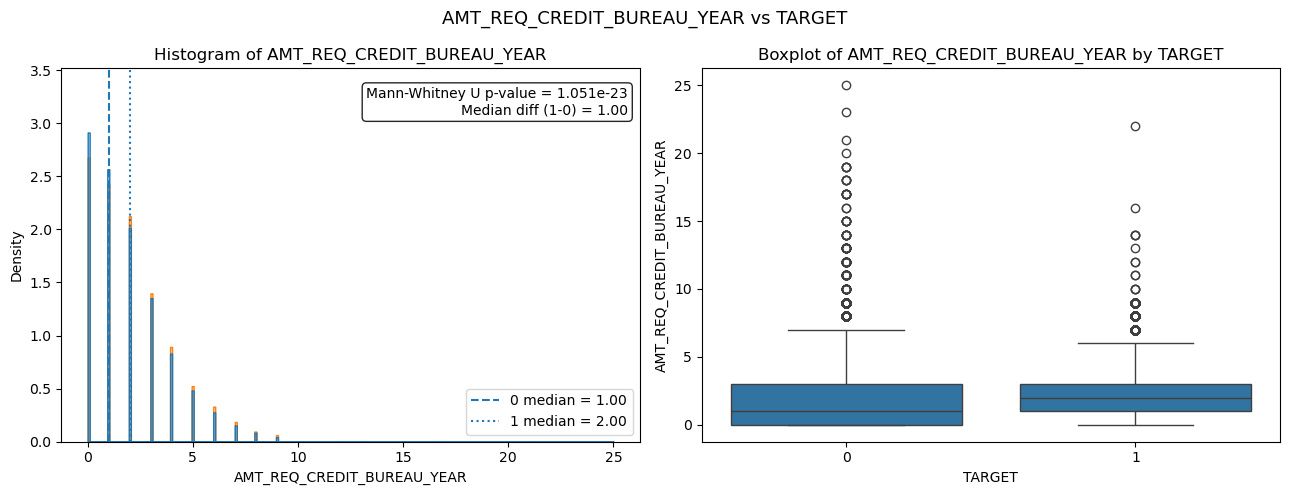

In [69]:
plot_quantitative_distribution(df=app_df, quant_var='AMT_REQ_CREDIT_BUREAU_YEAR')
plot_quantitative_vs_binary(df=app_df, quant_var='AMT_REQ_CREDIT_BUREAU_YEAR', target_var='TARGET')

We will proceed with just `AMT_REQ_CREDIT_BUREAU_YEAR` since it combines information from other CREDIT_BUREAU columns, it has no clearly invalid values, and since it is annual it should be less noisy than others.

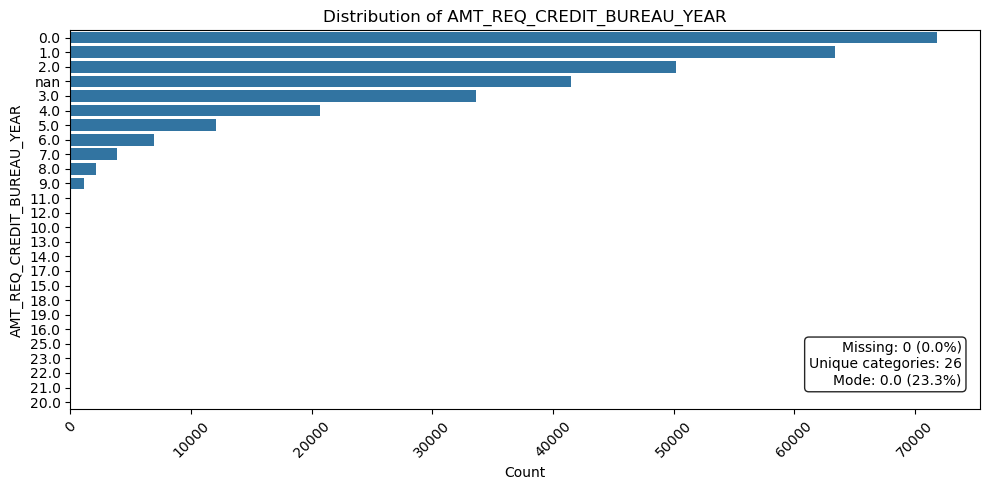

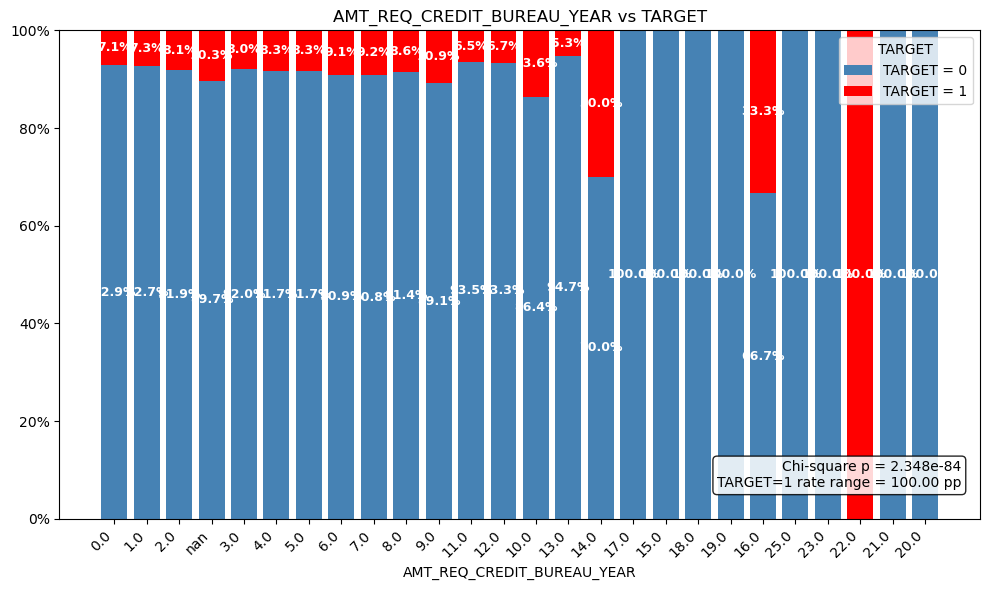

In [70]:
plot_categorical_distribution(
    df=app_df.assign(AMT_REQ_CREDIT_BUREAU_YEAR = app_df['AMT_REQ_CREDIT_BUREAU_YEAR'].astype(str)),
    cat_var='AMT_REQ_CREDIT_BUREAU_YEAR'
)
plot_categorical_vs_binary(
    df=app_df.assign(AMT_REQ_CREDIT_BUREAU_YEAR = app_df['AMT_REQ_CREDIT_BUREAU_YEAR'].astype(str)), 
    cat_var='AMT_REQ_CREDIT_BUREAU_YEAR', 
    target_var='TARGET'
)

We will try to group up the values since there are significant number of observations only for values < 10. Then we will treat this variable as categorical.

In [71]:
app_df['AMT_REQ_CREDIT_BUREAU_YEAR'].isna().sum()

np.int64(41519)

In [72]:
app_df['AMT_REQ_CREDIT_BUREAU_YEAR'].astype(str).isna().sum()

np.int64(0)

In [73]:
app_df['AMT_REQ_CREDIT_BUREAU_YEAR'].astype(str).value_counts()

AMT_REQ_CREDIT_BUREAU_YEAR
0.0     71801
1.0     63405
2.0     50192
nan     41519
3.0     33628
4.0     20714
5.0     12052
6.0      6967
7.0      3869
8.0      2127
9.0      1096
11.0       31
12.0       30
10.0       22
13.0       19
14.0       10
17.0        7
15.0        6
18.0        4
19.0        4
16.0        3
25.0        1
23.0        1
22.0        1
21.0        1
20.0        1
Name: count, dtype: int64

In [74]:
app_df['AMT_REQ_CREDIT_BUREAU_YEAR_grouped'] = np.where(
    app_df['AMT_REQ_CREDIT_BUREAU_YEAR'].isna(),
    'missing',
    np.where(
        app_df['AMT_REQ_CREDIT_BUREAU_YEAR'] < 10,
        app_df['AMT_REQ_CREDIT_BUREAU_YEAR'].astype(str),
        '> 9'
    )
)

app_df['AMT_REQ_CREDIT_BUREAU_YEAR_grouped'].value_counts()

AMT_REQ_CREDIT_BUREAU_YEAR_grouped
0.0        71801
1.0        63405
2.0        50192
missing    41519
3.0        33628
4.0        20714
5.0        12052
6.0         6967
7.0         3869
8.0         2127
9.0         1096
> 9          141
Name: count, dtype: int64

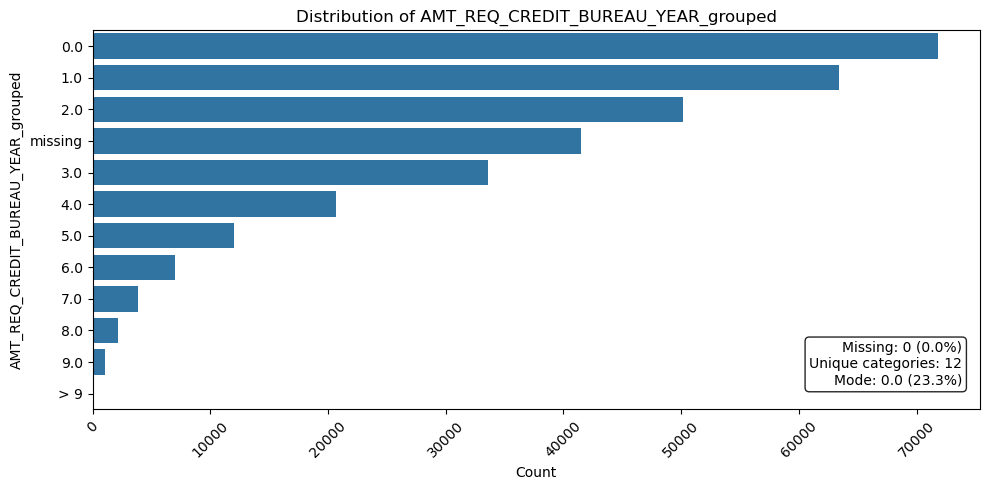

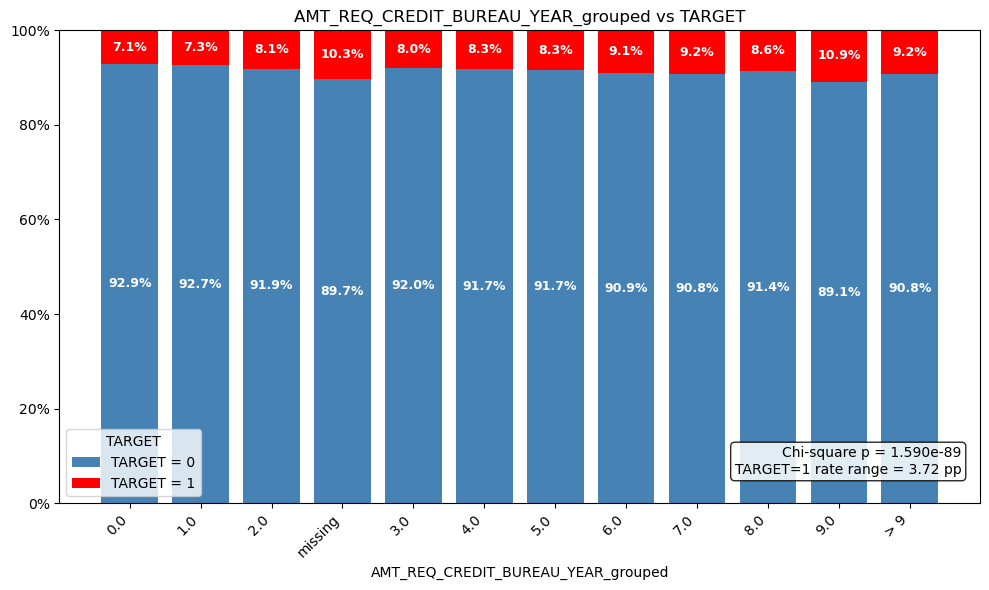

In [75]:
plot_categorical_distribution(df=app_df, cat_var='AMT_REQ_CREDIT_BUREAU_YEAR_grouped')
plot_categorical_vs_binary(df=app_df, cat_var='AMT_REQ_CREDIT_BUREAU_YEAR_grouped', target_var='TARGET')

In [76]:
app_df['AMT_REQ_CREDIT_BUREAU_YEAR_grouped'] = np.where(
    app_df['AMT_REQ_CREDIT_BUREAU_YEAR'].isna(),
    'missing',
    np.where(
        app_df['AMT_REQ_CREDIT_BUREAU_YEAR'].isin([0.0, 1.0]),
        '0-1',
        np.where(
            app_df['AMT_REQ_CREDIT_BUREAU_YEAR'].isin([2.0,3.0,4.0,5.0]),
            '2-5',
            '> 5'
        )
    )
)

app_df['AMT_REQ_CREDIT_BUREAU_YEAR_grouped'].value_counts()

AMT_REQ_CREDIT_BUREAU_YEAR_grouped
0-1        135206
2-5        116586
missing     41519
> 5         14200
Name: count, dtype: int64

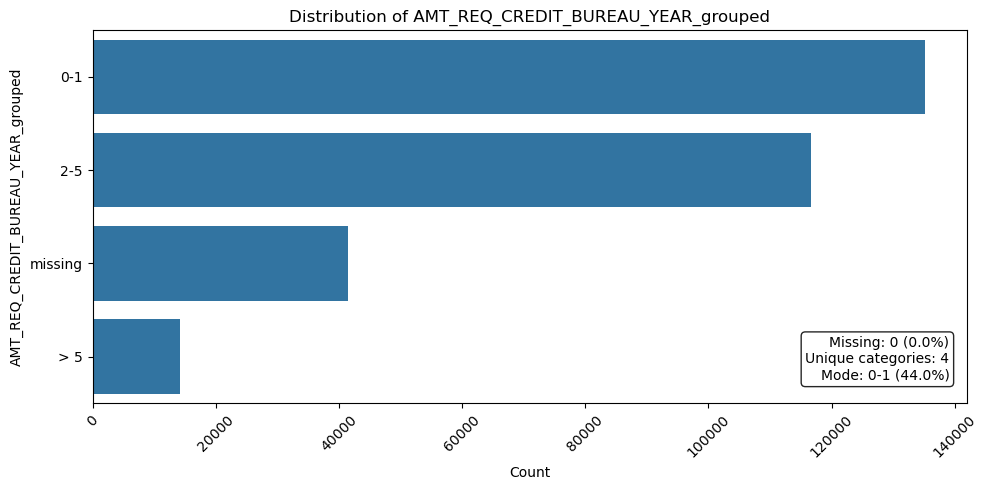

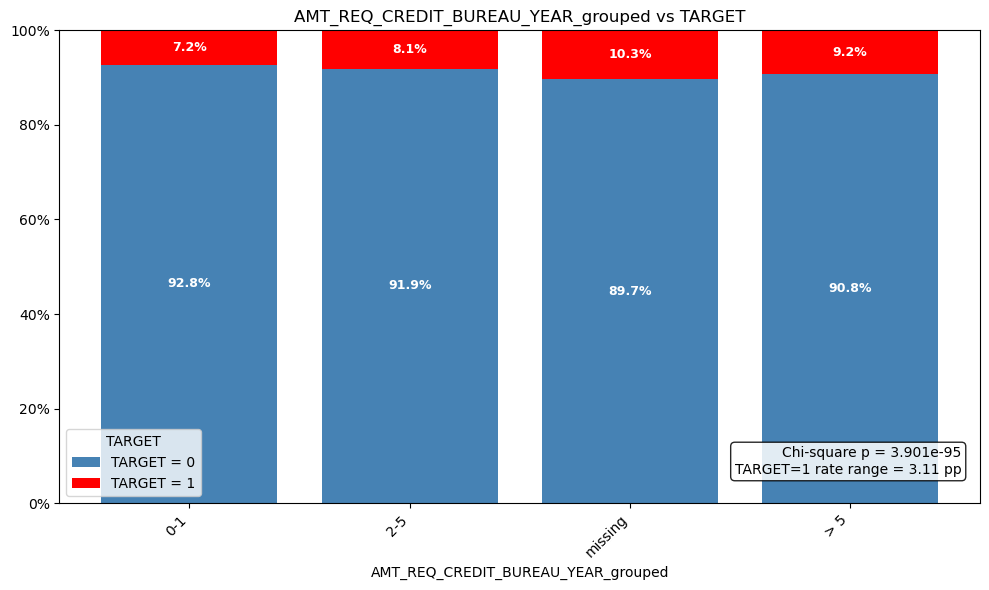

In [77]:
plot_categorical_distribution(df=app_df, cat_var='AMT_REQ_CREDIT_BUREAU_YEAR_grouped')
plot_categorical_vs_binary(df=app_df, cat_var='AMT_REQ_CREDIT_BUREAU_YEAR_grouped', target_var='TARGET')

There is no need to impute this categorical variable, we will treat NANs as a separate category.

## 7. Application CREDIT_BUREAU summary
Variables that should be used as predictors
- `AMT_REQ_CREDIT_BUREAU_YEAR_grouped`